Advertising Sales Prediction using Linear Regression

This project analyzes how advertising expenditures across TV, Radio, and Newspaper channels influence product sales. A linear regression model is built to predict Sales based on advertising spend, and model performance is evaluated using multiple metrics and visualizations.

## Import Libraries

In [20]:
import pandas as pd

## Load the Dataset

In [21]:
df = pd.read_csv("Advertising.csv")

## Exploratory Data Analysis (EDA)

In [22]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [23]:
df = df.drop(columns=["Unnamed: 0"])

In [24]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [26]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [27]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


Exploratory Data Analysis (EDA)

The dataset contains 200 observations and 4 variables: TV, Radio, Newspaper, and Sales.

All variables are numeric (float) and there are no missing values, so the dataset is clean and ready for modeling.

From the descriptive statistics, TV advertising has the largest average spending, followed by Newspaper and Radio.

The correlation analysis shows that TV advertising has the strongest relationship with Sales (≈0.78), followed by Radio (≈0.58).
Newspaper advertising shows a weak correlation with Sales (≈0.23), suggesting it may have a smaller effect on predicting sales.

## Preparing Data for Modeling

In [28]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [31]:
print(X_train.shape)
print(X_test.shape)

(140, 3)
(60, 3)


Train-Test Split

The dataset was split into training (70%) and testing (30%) subsets using train_test_split.
The training set contains 140 observations, while the test set contains 60 observations.
The training data will be used to build the regression model, and the test data will be used to evaluate its predictive performance.

## Linear Regression Model

In [32]:
from sklearn.linear_model import LinearRegression

In [33]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Model Evaluation Metrics

In [34]:
model.intercept_

np.float64(2.7089490925159065)

In [35]:
model.coef_

array([0.04405928, 0.1992875 , 0.00688245])

Model Coefficients

The intercept and coefficients above represent the parameters of the linear regression model relating advertising expenditures (TV, Radio, Newspaper) to Sales. These values are used to construct the regression equation and interpret how each advertising channel affects predicted sales.

In [36]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [38]:
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mape = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Test metrics
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print("TRAIN METRICS")
print("R2:", train_r2)
print("MAE:", train_mae)
print("RMSE:", train_rmse)
print("MAPE:", train_mape)

print("\nTEST METRICS")
print("R2:", test_r2)
print("MAE:", test_mae)
print("RMSE:", test_rmse)
print("MAPE:", test_mape)

TRAIN METRICS
R2: 0.9055159502227753
MAE: 1.1581502948072526
RMSE: 1.574596830590544
MAPE: 13.583791147559104

TEST METRICS
R2: 0.8609466508230368
MAE: 1.5116692224549086
RMSE: 1.9485372043446387
MAPE: 16.298720118158336


## Model Performance Visualization

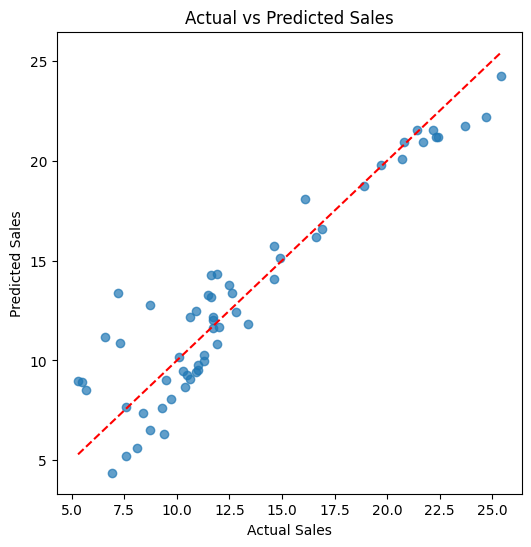

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.7)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

# Plot perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.show()

## Key Insights

Model Performance Visualization

The scatter plot compares the actual Sales values with the predicted Sales values from the test dataset.
The red dashed line represents perfect predictions where predicted values equal actual values.

Most observations lie close to this line, indicating that the regression model predicts Sales reasonably well and captures the overall relationship between advertising expenditures and sales.

Model Evaluation and Key Insights
Predictive Performance

The regression model performs well for prediction. The R² value on the test dataset is approximately 0.86, meaning the model explains about 86% of the variance in Sales. The training and testing R² values are close, suggesting the model generalizes well and does not show strong overfitting.

Effect of Advertising Channels

TV advertising shows the strongest relationship with Sales, consistent with the correlation observed during the exploratory data analysis. Radio advertising also has a meaningful positive effect on Sales. Newspaper advertising has a very small coefficient, indicating that it contributes minimally to the predictive power of the model in this dataset.

Variance Explained

Together, the three predictors (TV, Radio, and Newspaper) explain approximately 86% of the variance in Sales, based on the R² value from the test dataset.

Variance Explained

Together, the three predictors (TV, Radio, and Newspaper) explain approximately 86% of the variance in Sales, based on the R² value from the test dataset.

Percentage Error

The Mean Absolute Percentage Error (MAPE) is approximately 16.3%, indicating that predictions differ from actual Sales values by about 16% on average.